In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\MSI\freight-rate-ml\train-test.csv")

In [5]:
print(df.columns.tolist())
print(df.shape)
print(df.dtypes)

['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']
(48000, 14)
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object


In [6]:
print(df.head())

     load_id        pickup      delivery  pickup_lat  pickup_lon  \
0  TR-000001      Richmond     Baltimore    38.09122   -76.78906   
1  TR-000002      Richmond  Philadelphia    38.09122   -76.78906   
2  TR-000003  Philadelphia     Green Bay    39.22317   -72.96710   
3  TR-000004      Hartford       Atlanta    39.55328   -72.18051   
4  TR-000005        Dallas     Nashville    31.83025   -94.38343   

   delivery_lat  delivery_lon  distance equipment   weight        date  \
0      38.16908     -72.74564     274.3   Dry Van  30658.0  2025-01-01   
1      39.22317     -72.96710     280.5    Reefer  17555.0  2025-01-01   
2      44.30296     -87.52871     967.8   Dry Van  31721.0  2025-01-01   
3      34.84933     -86.28940     965.4   Dry Van  32333.0  2025-01-01   
4      35.29479     -88.08915     541.9    Reefer  35183.0  2025-01-01   

   market_index  quote_signal  posted_rate  
0       0.95684       2.39595       645.41  
1       0.97623       2.43355       679.97  
2       1.0

In [7]:
df.isnull().sum()
df.duplicated().sum()
df.nunique()
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [8]:
print("MISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

print("\nUNIQUE VALUES")
print(df.nunique())

MISSING VALUES
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

DUPLICATE ROWS
0

UNIQUE VALUES
load_id         48000
pickup             64
delivery           64
pickup_lat         64
pickup_lon         63
delivery_lat       64
delivery_lon       63
distance        21204
equipment           3
weight          23678
date              304
market_index    32884
quote_signal    37633
posted_rate     45398
dtype: int64


In [9]:
print("\nCATEGORICAL VALUES")

for col in df.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print("Unique:", df[col].nunique())
    print(df[col].value_counts().head(20))


CATEGORICAL VALUES

--- load_id ---
Unique: 48000
load_id
TR-000001    1
TR-000002    1
TR-000003    1
TR-000004    1
TR-000005    1
TR-000006    1
TR-000007    1
TR-000008    1
TR-000009    1
TR-000010    1
TR-000011    1
TR-000012    1
TR-000013    1
TR-000014    1
TR-000015    1
TR-000016    1
TR-000017    1
TR-000018    1
TR-000019    1
TR-000020    1
Name: count, dtype: int64

--- pickup ---
Unique: 64
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Cincinnati       1080
Shreveport       1062
Kansas City      1053
Columbia         1049
Atlanta          1029
San Antonio       972
Philadelphia      946
Los Angeles       945
Milwaukee         944
Tucson            944
Name: count, dtype: int64

--- delivery ---
Unique: 64
delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield

In [10]:
print("\nWEIGHT <= 0")
print(df[df["weight"] <= 0][["load_id", "weight", "distance", "equipment", "posted_rate"]].head(20))

print("\nNEGATIVE WEIGHT COUNT")
print((df["weight"] < 0).sum())

print("\nZERO WEIGHT COUNT")
print((df["weight"] == 0).sum())


WEIGHT <= 0
        load_id   weight  distance equipment  posted_rate
68    TR-000069 -36559.0    1334.2    Reefer      2831.27
204   TR-000205 -26670.0     496.2   Dry Van      1046.92
206   TR-000207 -20003.0     411.3    Reefer       959.15
225   TR-000226 -23981.0    1317.4    Reefer      2836.00
376   TR-000377 -41397.0    1331.1   Dry Van      2522.54
446   TR-000447 -37215.0    2438.3    Reefer      4841.57
495   TR-000496 -31214.0     715.9   Dry Van      1473.78
641   TR-000642 -41023.0     582.4   Dry Van      1264.33
806   TR-000807 -28320.0     676.1   Dry Van      1307.76
1093  TR-001094 -25153.0    1058.5   Dry Van      1907.83
1347  TR-001348 -25569.0     773.5   Dry Van      1529.40
1350  TR-001351 -33033.0     607.7   Dry Van      1211.22
1529  TR-001530 -31309.0    1052.8   Dry Van      1982.49
1618  TR-001619 -39700.0     784.5   Dry Van      1634.52
1687  TR-001688 -21304.0    1277.4   Flatbed      2414.39
1716  TR-001717 -19389.0     788.5   Dry Van      1456.42
1

In [11]:
# Investigate negative weights

negative = df[df["weight"] < 0]
normal = df[df["weight"] > 0]

print("NEGATIVE WEIGHT")
print(negative["posted_rate"].describe())

print("\nNORMAL WEIGHT")
print(normal["posted_rate"].describe())

print("\nNegative weight by equipment:")
print(negative["equipment"].value_counts())

print("\nNegative weight by month:")
print(
    pd.to_datetime(negative["date"])
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

print("\nCorrelation with posted rate:")
print(
    df[
        ["distance", "weight", "market_index", "quote_signal", "posted_rate"]
    ].corr()["posted_rate"]
)

NEGATIVE WEIGHT
count      292.000000
mean      2389.786233
std       1641.761285
min        247.370000
25%       1257.410000
50%       1994.960000
75%       3185.257500
max      14561.210000
Name: posted_rate, dtype: float64

NORMAL WEIGHT
count    47408.000000
mean      2374.030869
std       1486.103110
min         57.220000
25%       1251.712500
50%       2031.440000
75%       3330.790000
max      25533.000000
Name: posted_rate, dtype: float64

Negative weight by equipment:
equipment
Dry Van    155
Flatbed     70
Reefer      67
Name: count, dtype: int64

Negative weight by month:
date
2025-01    31
2025-02    30
2025-03    40
2025-04    25
2025-05    40
2025-06    30
2025-07    22
2025-08    15
2025-09    26
2025-10    33
Freq: M, Name: count, dtype: int64

Correlation with posted rate:
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
posted_rate     1.000000
Name: posted_rate, dtype: float64


In [14]:
print("Date range:", df["date"].min(), "→", df["date"].max())

print("\nDate counts:")
print(df["date"].value_counts().sort_index().head(20))

print("\nLast dates:")
print(df["date"].value_counts().sort_index().tail(20))

Date range: 2025-01-01 → 2025-10-31

Date counts:
date
2025-01-01    145
2025-01-02    168
2025-01-03    156
2025-01-04    156
2025-01-05    154
2025-01-06    168
2025-01-07    161
2025-01-08    189
2025-01-09    148
2025-01-10    173
2025-01-11    154
2025-01-12    158
2025-01-13    160
2025-01-14    164
2025-01-15    147
2025-01-16    148
2025-01-17    157
2025-01-18    163
2025-01-19    153
2025-01-20    151
Name: count, dtype: int64

Last dates:
date
2025-10-12    156
2025-10-13    158
2025-10-14    159
2025-10-15    147
2025-10-16    141
2025-10-17    181
2025-10-18    167
2025-10-19    149
2025-10-20    176
2025-10-21    155
2025-10-22    147
2025-10-23    156
2025-10-24    125
2025-10-25    164
2025-10-26    148
2025-10-27    148
2025-10-28    131
2025-10-29    164
2025-10-30    177
2025-10-31    176
Name: count, dtype: int64


In [12]:
# Investigate pickup/delivery coordinate consistency

same_location = (
    (df["pickup_lat"] == df["delivery_lat"]) &
    (df["pickup_lon"] == df["delivery_lon"])
)

print("Same pickup/delivery coordinates:", same_location.sum())

print("\nExamples:")
print(
    df.loc[
        same_location,
        ["load_id", "pickup", "delivery", "distance", "posted_rate"]
    ].head(20)
)

Same pickup/delivery coordinates: 0

Examples:
Empty DataFrame
Columns: [load_id, pickup, delivery, distance, posted_rate]
Index: []


In [13]:
validation = pd.read_csv(
    r"C:\Users\MSI\freight-rate-ml\validation.csv"
)

print("Shape:", validation.shape)

print("\nColumns:")
print(validation.columns.tolist())

print("\nData types:")
print(validation.dtypes)

print("\nMissing values:")
print(validation.isnull().sum())

print("\nDate range:")
print(validation["date"].min(), "→", validation["date"].max())

print("\nFirst 5 rows:")
print(validation.head())

Shape: (12000, 13)

Columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

Data types:
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
dtype: object

Missing values:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64

Date range:
2025-11-01 → 2025-12-31

First 5 rows:
     load_id         pickup     delivery  pickup_lat  pickup_lon  \
0  TE-000001    Baton Rouge       Mobile    30.50134 

Matplotlib is building the font cache; this may take a moment.


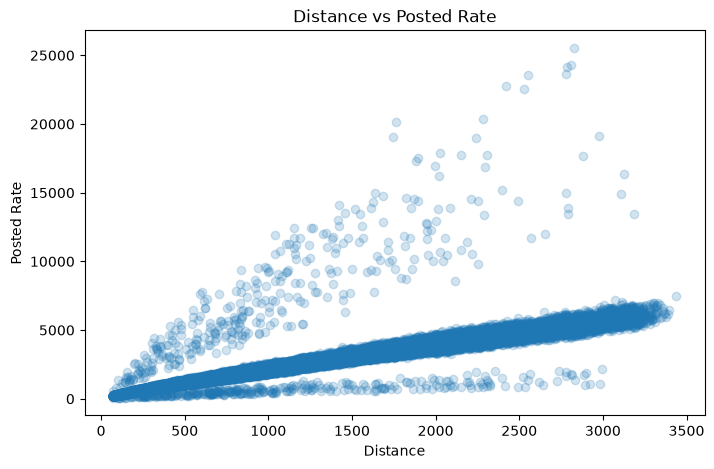

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["distance"], df["posted_rate"], alpha=0.2)
plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.title("Distance vs Posted Rate")
plt.show()

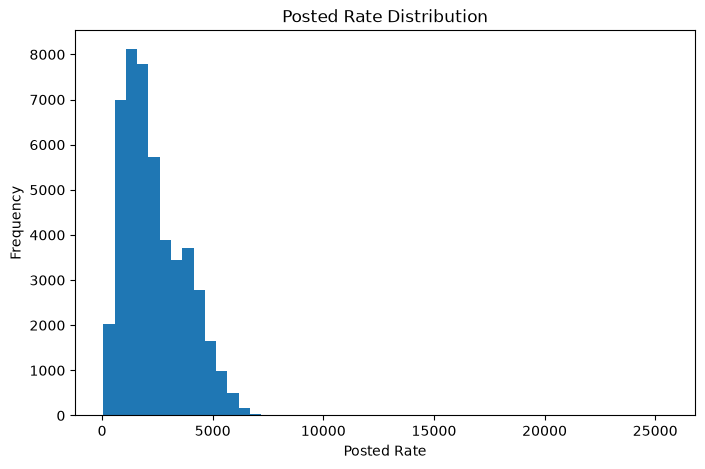

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df["posted_rate"], bins=50)
plt.xlabel("Posted Rate")
plt.ylabel("Frequency")
plt.title("Posted Rate Distribution")
plt.show()

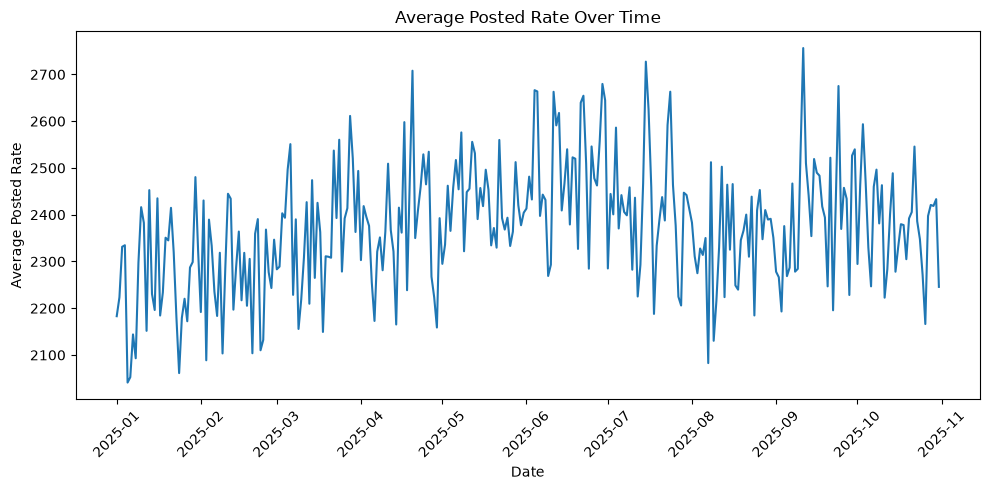

In [16]:
plot_df = df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

daily_rate = plot_df.groupby("date")["posted_rate"].mean()

plt.figure(figsize=(10, 5))
plt.plot(daily_rate)
plt.xlabel("Date")
plt.ylabel("Average Posted Rate")
plt.title("Average Posted Rate Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
december = pd.read_csv(
    r"C:\Users\MSI\freight-rate-ml\december-chart-inputs.csv"
)

print("Shape:", december.shape)

print("\nColumns:")
print(december.columns.tolist())

print("\nData types:")
print(december.dtypes)

print("\nMissing values:")
print(december.isnull().sum())

print("\nDate range:")
print(december["date"].min(), "→", december["date"].max())

print("\nFirst 5 rows:")
print(december.head())

Shape: (31, 7)

Columns:
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

Data types:
pickup             object
delivery           object
distance            int64
equipment          object
weight              int64
date               object
predicted_rate    float64
dtype: object

Missing values:
pickup             0
delivery           0
distance           0
equipment          0
weight             0
date               0
predicted_rate    31
dtype: int64

Date range:
2025-12-01 → 2025-12-31

First 5 rows:
      pickup    delivery  distance equipment  weight        date  \
0  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
1  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
2  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
3  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
4  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   

   predicted_rate  
0             NaN  
1   

In [22]:
print(december.columns.tolist())
print(december.shape)
print(december.dtypes)

['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
(31, 7)
pickup             object
delivery           object
distance            int64
equipment          object
weight              int64
date               object
predicted_rate    float64
dtype: object


In [24]:
with open(r"C:\Users\MSI\freight-rate-ml\score.py", "r") as f:
    print(f.read())

from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


EXPECTED_ROWS = 12_000
EXPECTED_IDS = {f"TE-{index:06d}" for index in range(1, EXPECTED_ROWS + 1)}
DECEMBER_DATES = pd.date_range("2025-12-01", "2025-12-31", freq="D")
FIXED_PICKUP = "Lexington"
FIXED_DELIVERY = "Fort Wayne"
FIXED_DISTANCE = 360.0
FIXED_EQUIPMENT = "Dry Van"
FIXED_WEIGHT = 32_000.0


def fail(message: str) -> None:
    raise SystemExit(f"ERROR: {message}")


def read_csv(path: Path, label: str) -> pd.DataFrame:
    if not path.is_file():
        fail(f"{label} file not found: {path}")
    try:
        return pd.read_csv(path)
    except Exception as exc:
        fail(f"could not read {label}: {exc}")


def numeric_series(frame: pd.DataFrame, column: str, label: str) -> pd.Series:
    values = pd.to_numeric(frame[column], errors="coerce")
    if values.isna().any() or not np.isfini

In [25]:
# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Chronological train/validation split
train_data = df[df["date"] < "2025-10-01"].copy()
valid_data = df[df["date"] >= "2025-10-01"].copy()

print("Training rows:", len(train_data))
print("Validation rows:", len(valid_data))

print("\nTraining period:")
print(train_data["date"].min(), "→", train_data["date"].max())

print("\nValidation period:")
print(valid_data["date"].min(), "→", valid_data["date"].max())

print("\nTraining target:")
print(train_data["posted_rate"].describe())

print("\nValidation target:")
print(valid_data["posted_rate"].describe())

Training rows: 43147
Validation rows: 4853

Training period:
2025-01-01 00:00:00 → 2025-09-30 00:00:00

Validation period:
2025-10-01 00:00:00 → 2025-10-31 00:00:00

Training target:
count    43147.000000
mean      2373.410351
std       1481.686233
min         57.220000
25%       1254.220000
50%       2029.700000
75%       3332.930000
max      25533.000000
Name: posted_rate, dtype: float64

Validation target:
count     4853.000000
mean      2379.051374
std       1528.714038
min        104.380000
25%       1231.130000
50%       2035.900000
75%       3305.450000
max      19110.300000
Name: posted_rate, dtype: float64


In [26]:
import numpy as np

# Get training features and target
X_train = train_data["distance"].values
y_train = train_data["posted_rate"].values

# Fit a simple linear regression using NumPy
slope, intercept = np.polyfit(X_train, y_train, 1)

print("Slope:", slope)
print("Intercept:", intercept)

# Predict on validation data
X_valid = valid_data["distance"].values
y_valid = valid_data["posted_rate"].values

valid_predictions = slope * X_valid + intercept

# Calculate errors
mae = np.mean(np.abs(y_valid - valid_predictions))
rmse = np.sqrt(np.mean((y_valid - valid_predictions) ** 2))

print("\nBaseline results:")
print("MAE:", mae)
print("RMSE:", rmse)

Slope: 1.8505996096291744
Intercept: 269.3385562314988

Baseline results:
MAE: 192.77419044195895
RMSE: 668.2130277041989


In [27]:
# Create a copy of the validation data
baseline_results = valid_data[[
    "load_id",
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "date",
    "posted_rate"
]].copy()

# Add predictions and errors
baseline_results["predicted_rate"] = valid_predictions

baseline_results["error"] = (
    baseline_results["posted_rate"]
    - baseline_results["predicted_rate"]
)

baseline_results["absolute_error"] = (
    baseline_results["error"].abs()
)

# Show the 10 largest errors
worst_predictions = baseline_results.sort_values(
    "absolute_error",
    ascending=False
).head(10)

worst_predictions

,load_id,pickup,delivery,distance,equipment,weight,date,posted_rate,predicted_rate,error,absolute_error
46213,TR-046214,Columbia,Tucson,2023.4,Flatbed,34710.0,2025-10-20,17893.17,4013.841806,13879.328194,13879.328194
43539,TR-043540,Milwaukee,Bakersfield,1893.0,Dry Van,30760.0,2025-10-03,17514.11,3772.523617,13741.586383,13741.586383
47298,TR-047299,Boston,Bakersfield,2979.1,Reefer,30585.0,2025-10-27,19110.30,5782.459853,13327.840147,13327.840147
46516,TR-046517,Toledo,Albuquerque,1684.3,Reefer,31536.0,2025-10-22,14784.38,3386.303479,11398.076521,11398.076521
46366,TR-046367,Bakersfield,Columbia,2251.9,Dry Van,40729.0,2025-10-21,14403.14,4436.703817,9966.436183,9966.436183
43302,TR-043303,Atlanta,Phoenix,2083.1,Reefer,40335.0,2025-10-01,13894.55,4124.322603,9770.227397,9770.227397
47536,TR-047537,Los Angeles,Richmond,2782.4,Dry Van,25730.0,2025-10-29,15003.55,5418.446910,9585.103090,9585.103090
44267,TR-044268,Albany,Albuquerque,2492.6,Dry Van,25513.0,2025-10-08,14425.42,4882.143143,9543.276857,9543.276857
43384,TR-043385,Lexington,Lubbock,1187.0,Dry Van,25359.0,2025-10-02,11696.44,2466.000293,9230.439707,9230.439707
47586,TR-047587,Corpus Christi,Las Vegas,1383.3,Flatbed,18645.0,2025-10-29,11596.28,2829.272996,8767.007004,8767.007004


In [30]:
# IQR outlier detection for posted_rate

Q1 = train_data["posted_rate"].quantile(0.25)
Q3 = train_data["posted_rate"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_data[
    (train_data["posted_rate"] < lower_bound) |
    (train_data["posted_rate"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nNumber of potential outliers:", len(outliers))
print("Percentage of training data:",
      len(outliers) / len(train_data) * 100, "%")

# How many IQR outliers are in each month?
outliers_by_month = (
    outliers
    .groupby(outliers["date"].dt.to_period("M"))
    .size()
)

print(outliers_by_month)

print("\nOutlier rate by equipment:")
print(outliers["equipment"].value_counts())

print("\nPotential outlier target statistics:")
print(outliers["posted_rate"].describe())

Q1: 1254.22
Q3: 3332.9300000000003
IQR: 2078.71

Lower bound: -1863.845
Upper bound: 6450.995000000001

Number of potential outliers: 228
Percentage of training data: 0.5284260782904953 %
date
2025-01    17
2025-02    15
2025-03    23
2025-04    20
2025-05    26
2025-06    46
2025-07    30
2025-08    21
2025-09    30
Freq: M, dtype: int64

Outlier rate by equipment:
equipment
Reefer     96
Dry Van    86
Flatbed    46
Name: count, dtype: int64

Potential outlier target statistics:
count      228.000000
mean      9919.066798
std       4034.109310
min       6452.260000
25%       6702.355000
50%       8591.905000
75%      11713.742500
max      25533.000000
Name: posted_rate, dtype: float64


In [31]:
correlations = train_data[
    [
        "distance",
        "weight",
        "market_index",
        "quote_signal",
        "posted_rate"
    ]
].corr()["posted_rate"].sort_values(ascending=False)

print(correlations)

posted_rate     1.000000
distance        0.909603
weight          0.037400
market_index    0.036158
quote_signal   -0.109459
Name: posted_rate, dtype: float64


In [32]:
equipment_rates = (
    train_data
    .groupby("equipment")["posted_rate"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

print(equipment_rates)

           count         mean   median
equipment                             
Reefer     10855  2541.936179  2181.88
Flatbed     7835  2446.892494  2082.11
Dry Van    24457  2275.071207  1957.39


In [33]:
# Create a route feature temporarily for exploration
train_data["route"] = (
    train_data["pickup"] + " → " + train_data["delivery"]
)

print("Unique routes:", train_data["route"].nunique())

print("\nMost common routes:")
print(train_data["route"].value_counts().head(15))

Unique routes: 4008

Most common routes:
route
Phoenix → Shreveport         38
Richmond → Phoenix           37
Lexington → Atlanta          36
Shreveport → Hartford        36
Columbia → Oklahoma City     35
Fort Wayne → Cincinnati      34
Oklahoma City → Columbia     34
Fort Wayne → Philadelphia    34
Fort Wayne → Hartford        34
Columbia → Montgomery        34
Lexington → Cincinnati       34
Oklahoma City → Atlanta      34
Richmond → Oklahoma City     33
Fort Wayne → Bakersfield     33
Oklahoma City → Nashville    33
Name: count, dtype: int64


In [34]:
route_counts = train_data["route"].value_counts()

print("Routes appearing once:", (route_counts == 1).sum())
print("Routes appearing 2-5 times:", route_counts.between(2, 5).sum())
print("Routes appearing 6-10 times:", route_counts.between(6, 10).sum())
print("Routes appearing more than 10 times:", (route_counts > 10).sum())

print("\nRoute frequency summary:")
print(route_counts.describe())

Routes appearing once: 83
Routes appearing 2-5 times: 845
Routes appearing 6-10 times: 1322
Routes appearing more than 10 times: 1758

Route frequency summary:
count    4008.000000
mean       10.765220
std         6.520362
min         1.000000
25%         6.000000
50%         9.000000
75%        15.000000
max        38.000000
Name: count, dtype: float64


In [35]:
train_data["month"] = train_data["date"].dt.month

monthly_rates = (
    train_data.groupby("month")["posted_rate"]
    .agg(["count", "mean", "median"])
)

print(monthly_rates)

       count         mean    median
month                              
1       4918  2255.967048  1915.200
2       4337  2273.804801  1994.250
3       5036  2372.268092  2022.920
4       4819  2372.162308  2044.240
5       4913  2421.776342  2065.510
6       4783  2497.030115  2120.220
7       4912  2415.162030  2059.145
8       4759  2338.407661  2015.730
9       4670  2406.374013  2057.130


In [36]:
weight_problem = train_data["weight"].isna() | (train_data["weight"] < 0)

print("Problematic weight rows:", weight_problem.sum())
print("Percentage:", round(weight_problem.mean() * 100, 2), "%")

print("\nTarget rate comparison:")
print(
    train_data.groupby(weight_problem)["posted_rate"]
    .agg(["count", "mean", "median"])
)

Problematic weight rows: 527
Percentage: 1.22 %

Target rate comparison:
        count         mean    median
weight                              
False   42620  2373.357988  2029.705
True      527  2377.645161  2020.590


In [38]:
pip install catboost 

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 6.7 MB/s eta 0:00:15
   --- ------------------------------------ 8.4/100.2 MB 27.5 MB/s eta 0:00:04
   ---- ----------------------------------- 11.0/100.2 MB 23.0 MB/s eta 0:00:04
   ----- ---------------------------------- 12.6/100.2 MB 17.5 MB/s eta 0:00:06
   ----- ---------------------------------- 14.9/100.2 MB 15.4 MB/s eta 0:00:06
   ------ --------------------------------- 16.5/100.2 MB 14.3 MB/s eta 0:00:06
   ------- -------------------------------- 18.4/100.2 MB 13.0 MB/s eta 0:00:07
   -------- ------------------------------- 22.3/100.2 MB 13.7 MB/s eta 0:00:06
   ---------- ----------------------------- 26.5/100.2 MB 14.3 MB/s eta 0:00:06
   ------------ --------------------------- 31.7/100.2 MB 15.4 MB/s eta 0:00:05
   ----------------- ---------------------- 43.5/100.2 MB 19.1 MB/s eta 0:00:03
   ---------------------- ----------------- 56.4/100

In [39]:
from catboost import CatBoostRegressor
print("catboost imported successfully")

catboost imported successfully


In [40]:
# Make a copy so we don't accidentally modify our original data
model_data = train_data.copy()

# Treat negative weights as invalid/missing
model_data.loc[model_data["weight"] < 0, "weight"] = np.nan

print("Missing/invalid weights after cleaning:",
      model_data["weight"].isna().sum())

Missing/invalid weights after cleaning: 527


In [41]:
model_data["route"] = (
    model_data["pickup"] + " → " + model_data["delivery"]
)

In [42]:
model_data["month"] = model_data["date"].dt.month
model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["day_of_year"] = model_data["date"].dt.dayofyear

In [43]:
features = [
    "pickup",
    "delivery",
    "route",
    "equipment",
    "distance",
    "weight",
    "month",
    "day_of_week",
    "day_of_year"
]

target = "posted_rate"

X_train = model_data[features]
y_train = model_data[target]

print("Features:")
print(features)

print("\nX shape:", X_train.shape)
print("y shape:", y_train.shape)

Features:
['pickup', 'delivery', 'route', 'equipment', 'distance', 'weight', 'month', 'day_of_week', 'day_of_year']

X shape: (43147, 9)
y shape: (43147,)


In [44]:
# Copy the October validation data
valid_model = valid_data.copy()

# Clean invalid weights
valid_model.loc[valid_model["weight"] < 0, "weight"] = np.nan

# Create the same route feature
valid_model["route"] = (
    valid_model["pickup"] + " → " + valid_model["delivery"]
)

# Create the same date features
valid_model["month"] = valid_model["date"].dt.month
valid_model["day_of_week"] = valid_model["date"].dt.dayofweek
valid_model["day_of_year"] = valid_model["date"].dt.dayofyear

# Create validation features and target
X_valid = valid_model[features]
y_valid = valid_model[target]

print("X_valid shape:", X_valid.shape)
print("y_valid shape:", y_valid.shape)

X_valid shape: (4853, 9)
y_valid shape: (4853,)


In [46]:
categorical_features = [
    "pickup",
    "delivery",
    "route",
    "equipment"
]

categorical_indices = [
    features.index(col) for col in categorical_features
]

print("Categorical columns:", categorical_features)
print("Categorical indices:", categorical_indices)

Categorical columns: ['pickup', 'delivery', 'route', 'equipment']
Categorical indices: [0, 1, 2, 3]


In [47]:
model = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_indices,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100
)

0:	learn: 1079.6501847	test: 1097.6956085	best: 1097.6956085 (0)	total: 247ms	remaining: 4m 6s
100:	learn: 112.4661224	test: 124.5224818	best: 124.5224818 (100)	total: 18s	remaining: 2m 39s
200:	learn: 99.4852742	test: 115.8421332	best: 115.4718849 (196)	total: 30.2s	remaining: 2m
Stopped by overfitting detector  (100 iterations wait)

bestTest = 115.4718849
bestIteration = 196

Shrink model to first 197 iterations.


CatBoostRegressor(depth=8, eval_metric='MAE', iterations=1000, learning_rate=0.05, loss_function='MAE', random_seed=42, verbose=100)

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predict October validation rates
cat_predictions = model.predict(X_valid)

# Calculate metrics
cat_mae = mean_absolute_error(y_valid, cat_predictions)
cat_rmse = np.sqrt(mean_squared_error(y_valid, cat_predictions))

print(f"CatBoost MAE:  {cat_mae:.2f}")
print(f"CatBoost RMSE: {cat_rmse:.2f}")

print("\nBaseline MAE:  192.77")
print("Baseline RMSE: 668.21")

CatBoost MAE:  115.47
CatBoost RMSE: 646.72

Baseline MAE:  192.77
Baseline RMSE: 668.21


In [52]:
#validation results table
validation_results = valid_model[
    ["load_id", "pickup", "delivery", "equipment", "distance", "weight", "date"]
].copy()

validation_results["actual_rate"] = y_valid.values
validation_results["predicted_rate"] = cat_predictions

validation_results["absolute_error"] = (
    abs(validation_results["actual_rate"] -
        validation_results["predicted_rate"])
)

# Show the 15 largest errors
worst_predictions = validation_results.sort_values(
    "absolute_error",
    ascending=False
).head(15)

worst_predictions

,load_id,pickup,delivery,equipment,distance,weight,date,actual_rate,predicted_rate,absolute_error
43539,TR-043540,Milwaukee,Bakersfield,Dry Van,1893.0,30760.0,2025-10-03,17514.11,3680.940032,13833.169968
46213,TR-046214,Columbia,Tucson,Flatbed,2023.4,34710.0,2025-10-20,17893.17,4222.030216,13671.139784
47298,TR-047299,Boston,Bakersfield,Reefer,2979.1,30585.0,2025-10-27,19110.30,6098.300065,13011.999935
46516,TR-046517,Toledo,Albuquerque,Reefer,1684.3,31536.0,2025-10-22,14784.38,3756.122839,11028.257161
47536,TR-047537,Los Angeles,Richmond,Dry Van,2782.4,25730.0,2025-10-29,15003.55,4888.453253,10115.096747
46366,TR-046367,Bakersfield,Columbia,Dry Van,2251.9,40729.0,2025-10-21,14403.14,4344.033458,10059.106542
44267,TR-044268,Albany,Albuquerque,Dry Van,2492.6,25513.0,2025-10-08,14425.42,4646.047079,9779.372921
43384,TR-043385,Lexington,Lubbock,Dry Van,1187.0,25359.0,2025-10-02,11696.44,2337.741551,9358.698449
43302,TR-043303,Atlanta,Phoenix,Reefer,2083.1,40335.0,2025-10-01,13894.55,4638.863596,9255.686404
47586,TR-047587,Corpus Christi,Las Vegas,Flatbed,1383.3,18645.0,2025-10-29,11596.28,3049.647851,8546.632149


In [53]:
# Define high-rate observations using the same IQR rule
q1 = train_data["posted_rate"].quantile(0.25)
q3 = train_data["posted_rate"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

high_rate = train_data["posted_rate"] > upper_bound

print("High-rate threshold:", round(upper_bound, 2))

print("\nWeight statistics:")
print(
    train_data.groupby(high_rate)["weight"]
    .agg(["count", "mean", "median", "min", "max"])
)

High-rate threshold: 6451.0

Weight statistics:
             count          mean   median      min      max
posted_rate                                                
False        42652  31023.241419  31424.0 -47500.0  47500.0
True           227  32312.255507  33214.0 -36413.0  47500.0


In [54]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
4,distance,88.271104
3,equipment,4.383610
0,pickup,2.279382
1,delivery,2.178901
5,weight,1.017211
8,day_of_year,0.942639
6,month,0.762424
7,day_of_week,0.164730
2,route,0.000000


In [55]:
equipment_model = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    verbose=100
)

equipment_features = ["distance", "equipment"]

equipment_cat_indices = [1]

equipment_model.fit(
    X_train[equipment_features],
    y_train,
    cat_features=equipment_cat_indices,
    eval_set=(X_valid[equipment_features], y_valid),
    early_stopping_rounds=100
)

equipment_predictions = equipment_model.predict(
    X_valid[equipment_features]
)

equipment_mae = mean_absolute_error(
    y_valid,
    equipment_predictions
)

equipment_rmse = np.sqrt(
    mean_squared_error(y_valid, equipment_predictions)
)

print(f"\nDistance + equipment MAE:  {equipment_mae:.2f}")
print(f"Distance + equipment RMSE: {equipment_rmse:.2f}")

0:	learn: 1075.7311068	test: 1095.1404996	best: 1095.1404996 (0)	total: 108ms	remaining: 1m 47s
100:	learn: 145.9352715	test: 141.5712806	best: 141.5712806 (100)	total: 11s	remaining: 1m 38s
200:	learn: 142.7944836	test: 137.4630028	best: 137.4616917 (199)	total: 17.8s	remaining: 1m 10s
300:	learn: 142.1991761	test: 137.1204330	best: 137.1194313 (299)	total: 25.7s	remaining: 59.8s
400:	learn: 141.7977745	test: 137.0100719	best: 137.0037006 (391)	total: 32.6s	remaining: 48.7s
500:	learn: 141.5615847	test: 136.9241452	best: 136.9241452 (500)	total: 39.6s	remaining: 39.4s
600:	learn: 141.3420819	test: 136.9031044	best: 136.8888721 (561)	total: 46.2s	remaining: 30.6s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 136.8888721
bestIteration = 561

Shrink model to first 562 iterations.

Distance + equipment MAE:  136.89
Distance + equipment RMSE: 653.80


In [56]:
features_no_route = [
    "pickup",
    "delivery",
    "equipment",
    "distance",
    "weight",
    "month",
    "day_of_week",
    "day_of_year"
]

X_train_no_route = model_data[features_no_route]
X_valid_no_route = valid_model[features_no_route]

categorical_no_route = [
    features_no_route.index("pickup"),
    features_no_route.index("delivery"),
    features_no_route.index("equipment")
]

model_no_route = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    verbose=100
)

model_no_route.fit(
    X_train_no_route,
    y_train,
    cat_features=categorical_no_route,
    eval_set=(X_valid_no_route, y_valid),
    early_stopping_rounds=100
)

no_route_predictions = model_no_route.predict(X_valid_no_route)

no_route_mae = mean_absolute_error(
    y_valid,
    no_route_predictions
)

no_route_rmse = np.sqrt(
    mean_squared_error(y_valid,
                       no_route_predictions)
)

print(f"\nNo-route CatBoost MAE:  {no_route_mae:.2f}")
print(f"No-route CatBoost RMSE: {no_route_rmse:.2f}")

0:	learn: 1075.6524498	test: 1094.1963985	best: 1094.1963985 (0)	total: 126ms	remaining: 2m 6s
100:	learn: 112.7595082	test: 124.7626951	best: 124.7626951 (100)	total: 13.7s	remaining: 2m 1s
200:	learn: 99.6345353	test: 116.7921581	best: 116.4351143 (189)	total: 23.8s	remaining: 1m 34s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 116.4351143
bestIteration = 189

Shrink model to first 190 iterations.

No-route CatBoost MAE:  116.44
No-route CatBoost RMSE: 647.43


In [57]:
# Create cyclical time features
model_data["day_sin"] = np.sin(
    2 * np.pi * model_data["day_of_year"] / 365
)

model_data["day_cos"] = np.cos(
    2 * np.pi * model_data["day_of_year"] / 365
)

valid_model["day_sin"] = np.sin(
    2 * np.pi * valid_model["day_of_year"] / 365
)

valid_model["day_cos"] = np.cos(
    2 * np.pi * valid_model["day_of_year"] / 365
)

cyclical_features = [
    "pickup",
    "delivery",
    "equipment",
    "distance",
    "weight",
    "month",
    "day_of_week",
    "day_of_year",
    "day_sin",
    "day_cos"
]

X_train_cyclical = model_data[cyclical_features]
X_valid_cyclical = valid_model[cyclical_features]

cyclical_cat_indices = [
    cyclical_features.index("pickup"),
    cyclical_features.index("delivery"),
    cyclical_features.index("equipment")
]

print("Training shape:", X_train_cyclical.shape)
print("Validation shape:", X_valid_cyclical.shape)

Training shape: (43147, 10)
Validation shape: (4853, 10)


In [58]:
cyclical_model = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    verbose=100
)

cyclical_model.fit(
    X_train_cyclical,
    y_train,
    cat_features=cyclical_cat_indices,
    eval_set=(X_valid_cyclical, y_valid),
    early_stopping_rounds=100
)

cyclical_predictions = cyclical_model.predict(
    X_valid_cyclical
)

cyclical_mae = mean_absolute_error(
    y_valid,
    cyclical_predictions
)

cyclical_rmse = np.sqrt(
    mean_squared_error(y_valid, cyclical_predictions)
)

print(f"\nCyclical CatBoost MAE:  {cyclical_mae:.2f}")
print(f"Cyclical CatBoost RMSE: {cyclical_rmse:.2f}")

0:	learn: 1076.3408556	test: 1094.7187770	best: 1094.7187770 (0)	total: 136ms	remaining: 2m 15s
100:	learn: 111.7703097	test: 127.8661746	best: 127.8661746 (100)	total: 12.5s	remaining: 1m 50s
200:	learn: 98.8878165	test: 117.6038046	best: 117.6038046 (200)	total: 23.6s	remaining: 1m 33s
300:	learn: 94.0231056	test: 116.4215320	best: 116.4215320 (300)	total: 32.4s	remaining: 1m 15s
400:	learn: 90.8291723	test: 116.1287633	best: 115.8719111 (399)	total: 41.1s	remaining: 1m 1s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 115.8719111
bestIteration = 399

Shrink model to first 400 iterations.

Cyclical CatBoost MAE:  115.87
Cyclical CatBoost RMSE: 647.99


In [59]:
# Copy the full training dataset
final_train = df.copy()

# Clean invalid negative weights
final_train.loc[final_train["weight"] < 0, "weight"] = np.nan

# Create date features
final_train["month"] = final_train["date"].dt.month
final_train["day_of_week"] = final_train["date"].dt.dayofweek
final_train["day_of_year"] = final_train["date"].dt.dayofyear

# Final feature set
final_features = [
    "pickup",
    "delivery",
    "equipment",
    "distance",
    "weight",
    "month",
    "day_of_week",
    "day_of_year"
]

X_final_train = final_train[final_features]
y_final_train = final_train["posted_rate"]

# Categorical feature positions
final_cat_indices = [
    final_features.index("pickup"),
    final_features.index("delivery"),
    final_features.index("equipment")
]

print("Training shape:", X_final_train.shape)
print("Target shape:", y_final_train.shape)
print("Categorical columns:", final_cat_indices)

Training shape: (48000, 8)
Target shape: (48000,)
Categorical columns: [0, 1, 2]


In [60]:
# Copy the full training dataset
final_train = df.copy()

# Clean invalid negative weights
final_train.loc[final_train["weight"] < 0, "weight"] = np.nan

# Create date features
final_train["month"] = final_train["date"].dt.month
final_train["day_of_week"] = final_train["date"].dt.dayofweek
final_train["day_of_year"] = final_train["date"].dt.dayofyear

# Final feature set
final_features = [
    "pickup",
    "delivery",
    "equipment",
    "distance",
    "weight",
    "month",
    "day_of_week",
    "day_of_year"
]

X_final_train = final_train[final_features]
y_final_train = final_train["posted_rate"]

# Categorical feature positions
final_cat_indices = [
    final_features.index("pickup"),
    final_features.index("delivery"),
    final_features.index("equipment")
]

print("Training shape:", X_final_train.shape)
print("Target shape:", y_final_train.shape)
print("Categorical columns:", final_cat_indices)

Training shape: (48000, 8)
Target shape: (48000,)
Categorical columns: [0, 1, 2]


In [63]:
# Copy the 12,000-row final validation dataset
final_valid = validation.copy()

# Make sure date is datetime
final_valid["date"] = pd.to_datetime(final_valid["date"])

# Clean invalid negative weights
final_valid.loc[final_valid["weight"] < 0, "weight"] = np.nan

# Create the same date features used for training
final_valid["month"] = final_valid["date"].dt.month
final_valid["day_of_week"] = final_valid["date"].dt.dayofweek
final_valid["day_of_year"] = final_valid["date"].dt.dayofyear

# Select exactly the same features and order as training
X_final_valid = final_valid[final_features]

print("Validation shape:", X_final_valid.shape)

print(
    "Validation date range:",
    final_valid["date"].min().date(),
    "→",
    final_valid["date"].max().date()
)

print("\nMissing values:")
print(X_final_valid.isna().sum())

Validation shape: (12000, 8)
Validation date range: 2025-11-01 → 2025-12-31

Missing values:
pickup           0
delivery         0
equipment        0
distance         0
weight         310
month            0
day_of_week      0
day_of_year      0
dtype: int64


In [64]:
final_model = CatBoostRegressor(
    iterations=200,
    depth=8,
    learning_rate=0.05,
    loss_function="MAE",
    random_seed=42,
    verbose=50
)

final_model.fit(
    X_final_train,
    y_final_train,
    cat_features=final_cat_indices
)

print("\nFinal model trained successfully.")

0:	learn: 1078.4565126	total: 105ms	remaining: 20.9s
50:	learn: 195.9996916	total: 6.6s	remaining: 19.3s
100:	learn: 112.8965920	total: 13.5s	remaining: 13.2s
150:	learn: 104.1192996	total: 19.3s	remaining: 6.25s
199:	learn: 100.6972676	total: 24.1s	remaining: 0us

Final model trained successfully.


In [65]:
# Predict rates for the 12,000 final validation loads
final_predictions = final_model.predict(X_final_valid)

print("Number of predictions:", len(final_predictions))
print("Minimum prediction:", final_predictions.min())
print("Maximum prediction:", final_predictions.max())
print("Mean prediction:", final_predictions.mean())
print("Missing predictions:", np.isnan(final_predictions).sum())

Number of predictions: 12000
Minimum prediction: 195.211830671308
Maximum prediction: 6612.435484453065
Mean prediction: 2369.949141186891
Missing predictions: 0


In [92]:
# Load the provided template
validation_template = pd.read_csv(r"C:\Users\MSI\freight-rate-ml\validation-predictions.csv")

# Fill the prediction column
validation_template["predicted_rate"] = final_predictions

# Save the completed file to the exact required location
output_path = r"C:\Users\MSI\freight-rate-ml\validation-predictions.csv"

validation_template.to_csv(
    output_path,
    index=False
)

print("Saved successfully to:")
print(output_path)

print("\nShape:", validation_template.shape)
print("Missing predictions:",
      validation_template["predicted_rate"].isna().sum())

Saved successfully to:
C:\Users\MSI\freight-rate-ml\validation-predictions.csv

Shape: (12000, 2)
Missing predictions: 0


In [94]:
december = pd.read_csv(
    r"C:\Users\MSI\freight-rate-ml\december-chart-inputs.csv"
)

december["date"] = pd.to_datetime(december["date"])

print("Shape:", december.shape)
print("\nColumns:", december.columns.tolist())

print("\nDate range:")
print(december["date"].min(), "→", december["date"].max())

print("\nMissing values:")
print(december.isna().sum())

print("\nFirst 5 rows:")
print(december.head())

Shape: (31, 7)

Columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

Date range:
2025-12-01 00:00:00 → 2025-12-31 00:00:00

Missing values:
pickup             0
delivery           0
distance           0
equipment          0
weight             0
date               0
predicted_rate    31
dtype: int64

First 5 rows:
      pickup    delivery  distance equipment  weight       date  \
0  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-01   
1  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-02   
2  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-03   
3  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-04   
4  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-05   

   predicted_rate  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  


In [95]:
# Clean invalid negative weights, if any
december.loc[december["weight"] < 0, "weight"] = np.nan

# Create the same date features used by the final model
december["month"] = december["date"].dt.month
december["day_of_week"] = december["date"].dt.dayofweek
december["day_of_year"] = december["date"].dt.dayofyear

# Select the exact same features used for final training
X_december = december[final_features]

print("December feature shape:", X_december.shape)

print("\nFeatures:")
print(X_december.columns.tolist())

print("\nFirst 5 feature rows:")
print(X_december.head())

December feature shape: (31, 8)

Features:
['pickup', 'delivery', 'equipment', 'distance', 'weight', 'month', 'day_of_week', 'day_of_year']

First 5 feature rows:
      pickup    delivery equipment  distance   weight  month  day_of_week  \
0  Lexington  Fort Wayne   Dry Van       360  32000.0     12            0   
1  Lexington  Fort Wayne   Dry Van       360  32000.0     12            1   
2  Lexington  Fort Wayne   Dry Van       360  32000.0     12            2   
3  Lexington  Fort Wayne   Dry Van       360  32000.0     12            3   
4  Lexington  Fort Wayne   Dry Van       360  32000.0     12            4   

   day_of_year  
0          335  
1          336  
2          337  
3          338  
4          339  


In [96]:
# Generate predictions for all 31 December dates
december_predictions = final_model.predict(X_december)

print("Number of predictions:", len(december_predictions))
print("Minimum prediction:", december_predictions.min())
print("Maximum prediction:", december_predictions.max())
print("Mean prediction:", december_predictions.mean())
print("Missing predictions:", np.isnan(december_predictions).sum())

Number of predictions: 31
Minimum prediction: 823.7264409497611
Maximum prediction: 845.2210666497608
Mean prediction: 836.5693007312849
Missing predictions: 0


In [98]:
# Fill the prediction column
december["predicted_rate"] = december_predictions

# Save the completed December file
december_output_path = r"C:\Users\MSI\freight-rate-ml\december_chart_inputs.csv"

december.to_csv(
    december_output_path,
    index=False
)

print("Saved successfully to:")
print(december_output_path)

print("\nShape:", december.shape)

print(
    "Missing predictions:",
    december["predicted_rate"].isna().sum()
)

print("\nDecember predictions:")
print(
    december[
        ["date", "pickup", "delivery", "distance", "equipment", "weight", "predicted_rate"]
    ].to_string(index=False)
)

Saved successfully to:
C:\Users\MSI\freight-rate-ml\december_chart_inputs.csv

Shape: (31, 10)
Missing predictions: 0

December predictions:
      date    pickup   delivery  distance equipment  weight  predicted_rate
2025-12-01 Lexington Fort Wayne       360   Dry Van 32000.0      830.073380
2025-12-02 Lexington Fort Wayne       360   Dry Van 32000.0      836.560330
2025-12-03 Lexington Fort Wayne       360   Dry Van 32000.0      844.295259
2025-12-04 Lexington Fort Wayne       360   Dry Van 32000.0      845.221067
2025-12-05 Lexington Fort Wayne       360   Dry Van 32000.0      843.335373
2025-12-06 Lexington Fort Wayne       360   Dry Van 32000.0      832.467988
2025-12-07 Lexington Fort Wayne       360   Dry Van 32000.0      823.726441
2025-12-08 Lexington Fort Wayne       360   Dry Van 32000.0      830.073380
2025-12-09 Lexington Fort Wayne       360   Dry Van 32000.0      836.560330
2025-12-10 Lexington Fort Wayne       360   Dry Van 32000.0      844.295259
2025-12-11 Lexington Fo

In [101]:
# Keep only the columns required by the original template
december_submission = december[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "predicted_rate"
    ]
].copy()

# Save using the ORIGINAL filename they provided
december_submission_path = (
    r"C:\Users\MSI\freight-rate-ml\december-chart-inputs.csv"
)

december_submission.to_csv(
    december_submission_path,
    index=False
)

print("Saved successfully to:")
print(december_submission_path)

print("\nShape:", december_submission.shape)
print("Columns:", list(december_submission.columns))
print("Missing predictions:", december_submission["predicted_rate"].isna().sum())

Saved successfully to:
C:\Users\MSI\freight-rate-ml\december-chart-inputs.csv

Shape: (31, 7)
Columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
Missing predictions: 0


In [102]:
import subprocess
import sys

project_path = r"C:\Users\MSI\freight-rate-ml"

result = subprocess.run(
    [
        sys.executable,
        "score.py",
        "--predictions",
        "validation-predictions.csv",
        "--december-predictions",
        "december-chart-inputs.csv"
    ],
    cwd=project_path,
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("\n--- Errors / Warnings ---")
    print(result.stderr)

print("\nReturn code:", result.returncode)

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.


Return code: 0
